In [39]:
import uproot
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
plt.style.use('belle2')
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
import glob
import os

import joblib

In [40]:
# Function to load and filter data from multiple files
def load_and_filter(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID', 'etapip_Eta_p', 'etapip_Eta_CMS_cosTheta','Dp_isSignal','etapip_Eta_cosTheta',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal', 'rank_Dp_chiProb']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [41]:
# Function to load and filter data from multiple files
def load_and_filter_ds_weight(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID', 'etapip_Eta_p', 'etapip_Eta_CMS_cosTheta','Dp_isSignal','etapip_Eta_cosTheta',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal','ds_weight', 'rank_Dp_chiProb']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [42]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = "Dp_isSignal==1"
cut_signal += ' & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi/260602_loose_v7_eta_theta_var/etapip_pipipi_K/min_unc_search/0.77/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi_cc/260602_loose_v7_eta_theta_var/etapip_pipipi_K/min_unc_search/0.77/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)
# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi_K",cut_signal)

norm_file = []
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi/260602_loose_v7_eta_theta_var/etapip_pipipi/ref/min_unc_search/0.77/*BDT.root")
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi_cc/260602_loose_v7_eta_theta_var/etapip_pipipi/ref/min_unc_search/0.77/*BDT.root")
norm_pattern = []
for element in norm_file:
    norm_pattern += glob.glob(element)
# print(norm_pattern)
df_ref = load_and_filter(norm_pattern, "etapip_pipipi",cut_signal)


In [43]:
# === Combine data and create labels ===
ref_tree = "etapip_pipipi_K"

# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['etapip_Eta_cosTheta', 'etapip_Eta_p']

df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_eta.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_eta.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_K_eta.pkl'


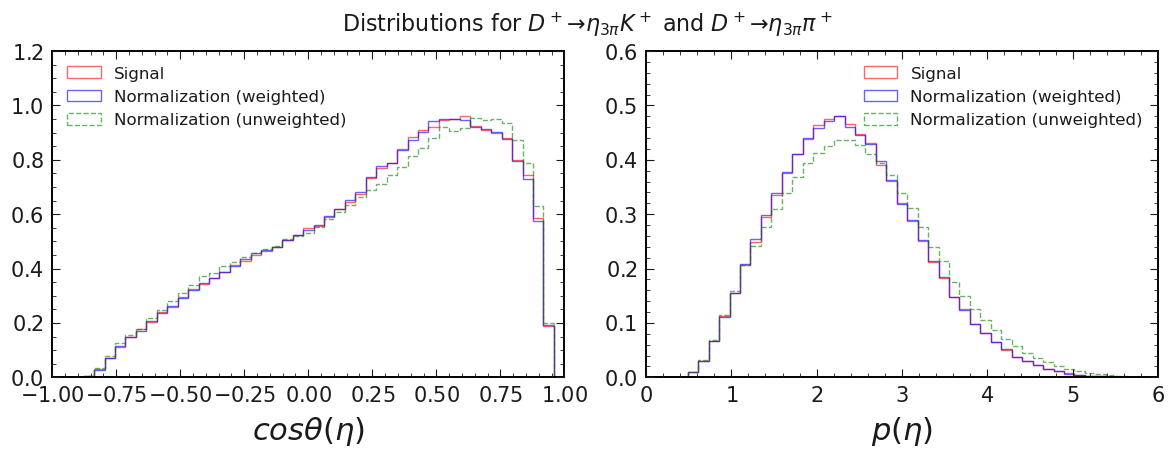

In [44]:
mode = r"$D^+ \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+ \to \eta_{3\pi} \pi^+$"
# === Plot distributions ===
bins_dict = {
    'etapip_Eta_cosTheta': np.linspace(-1, 1, 50),
    'etapip_Eta_p': np.linspace(0, 6, 50),
}

legend_loc = {
    'etapip_Eta_cosTheta': 'upper left',
    'etapip_Eta_p': 'upper right',
}
var_info = {
    'etapip_Eta_cosTheta': r'$cos\theta(\eta)$',
    'etapip_Eta_p': r'$p(\eta)$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Normalization (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Normalization (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"etapip_pipipi_K_2_vars_reweighting.pdf")
plt.show()

In [45]:
cut_signal = "Dp_isSignal==1"
cut_signal += ' & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/260602_loose_v7_eta_theta_var/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/260602_loose_v7_eta_theta_var/etapip_gg_K/min_unc_search/0.86/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)
# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg_K",cut_signal)

norm_file = []
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/260602_loose_v7_eta_theta_var/etapip_gg/ref/min_unc_search/0.86/*BDT.root")
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/260602_loose_v7_eta_theta_var/etapip_gg/ref/min_unc_search/0.86/*BDT.root")
norm_pattern = []
for element in norm_file:
    norm_pattern += glob.glob(element)
# print(norm_pattern)
df_ref = load_and_filter(norm_pattern, "etapip_gg",cut_signal)

In [46]:
# === Combine data and create labels ===
ref_tree = "etapip_gg_K"

# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['etapip_Eta_cosTheta', 'etapip_Eta_p']

df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_eta.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_eta.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_K_eta.pkl'


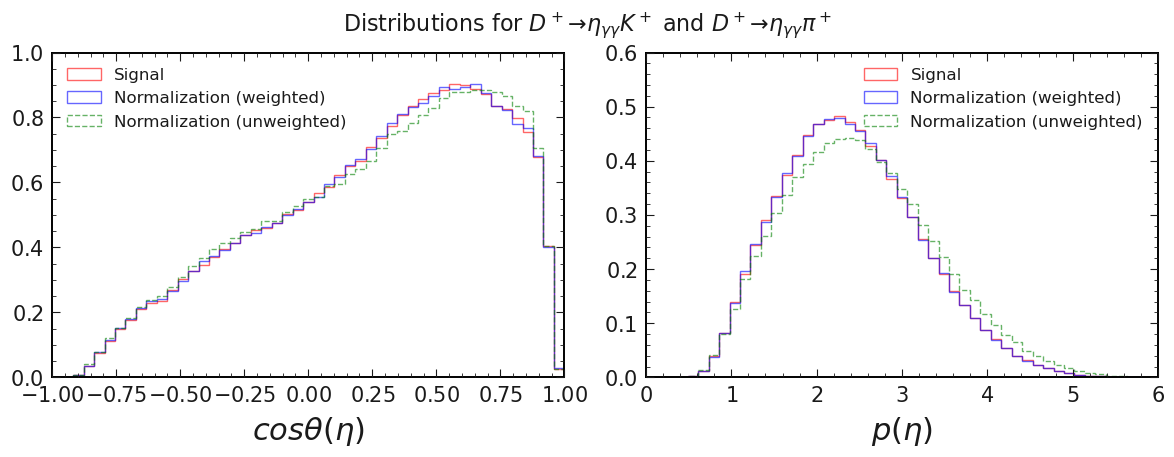

In [47]:
mode = r"$D^+ \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+ \to \eta_{\gamma\gamma} \pi^+$"
# === Plot distributions ===
bins_dict = {
    'etapip_Eta_cosTheta': np.linspace(-1, 1, 50),
    'etapip_Eta_p': np.linspace(0, 6, 50),
}

legend_loc = {
    'etapip_Eta_cosTheta': 'upper left',
    'etapip_Eta_p': 'upper right',
}
var_info = {
    'etapip_Eta_cosTheta': r'$cos\theta(\eta)$',
    'etapip_Eta_p': r'$p(\eta)$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Normalization (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Normalization (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"etapip_gg_K_2_vars_reweighting.pdf")
plt.show()

In [48]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dsp_K
cut_signal += ' & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi/260602_loose_v7_eta_theta_var/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_pipipi_cc/260602_loose_v7_eta_theta_var/etapip_pipipi_K/min_unc_search/0.77/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)
# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi_K",cut_signal)

cut_signal = signal_cut_Dsp_pi
cut_signal += ' & rank_Dp_chiProb==1'

norm_file = []
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi/260602_loose_v7_eta_theta_var/etapip_pipipi/ref/min_unc_search/0.77/weighted/*BDT.root")
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi_cc/260602_loose_v7_eta_theta_var/etapip_pipipi/ref/min_unc_search/0.77/weighted/*BDT.root")
norm_pattern = []
for element in norm_file:
    norm_pattern += glob.glob(element)
# print(norm_pattern)
df_ref = load_and_filter_ds_weight(norm_pattern, "etapip_pipipi",cut_signal)

In [49]:
# === Combine data and create labels ===
ref_tree = "etapip_pipipi_K"

# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['etapip_Eta_cosTheta', 'etapip_Eta_p']

df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)

# === Save model using joblib ===
joblib.dump(model, f"Ds_xgb_model_{ref_tree}_eta.pkl")
print(f"✅ Model saved to 'Ds_xgb_model_{ref_tree}_eta.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
# target_total = len(df_ref)
# actual_total = df_ref['weight'].sum()
# df_ref['weight'] *= target_total / actual_total

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'Ds_xgb_model_etapip_pipipi_K_eta.pkl'


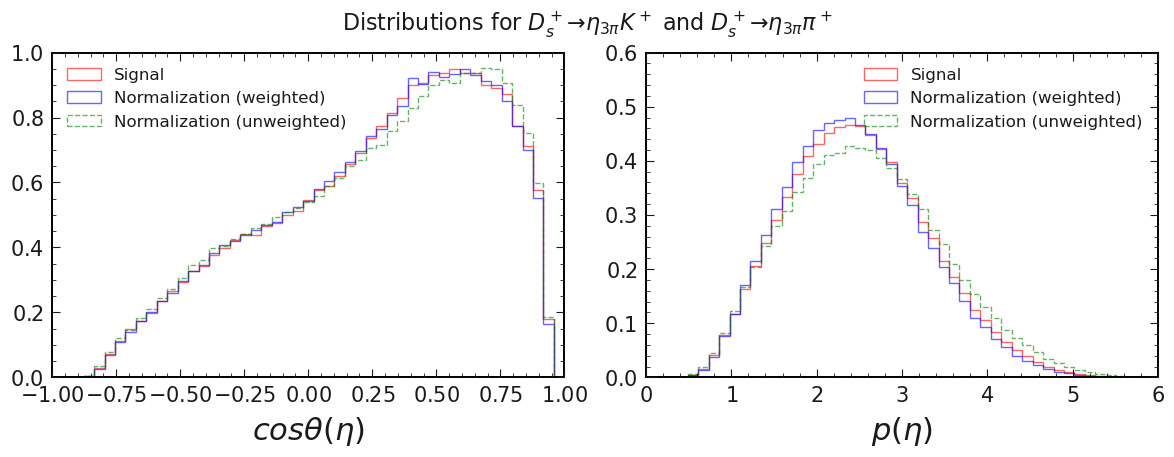

In [50]:
mode = r"$D^+_s \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+_s \to \eta_{3\pi} \pi^+$"
# === Plot distributions ===
bins_dict = {
    'etapip_Eta_cosTheta': np.linspace(-1, 1, 50),
    'etapip_Eta_p': np.linspace(0, 6, 50),
}

legend_loc = {
    'etapip_Eta_cosTheta': 'upper left',
    'etapip_Eta_p': 'upper right',
}
var_info = {
    'etapip_Eta_cosTheta': r'$cos\theta(\eta)$',
    'etapip_Eta_p': r'$p(\eta)$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Normalization (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Normalization (unweighted)', linestyle='--', color='green')

    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"Ds_etapip_pipipi_K_2_vars_reweighting.pdf")
plt.show()

In [51]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dsp_K
cut_signal += ' & rank_Dp_chiProb==1'

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/260602_loose_v7_eta_theta_var/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/260602_loose_v7_eta_theta_var/etapip_gg_K/min_unc_search/0.86/weighted/*BDT.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)
# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg_K",cut_signal)

cut_signal = signal_cut_Dsp_pi
cut_signal += ' & rank_Dp_chiProb==1'

norm_file = []
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg/260602_loose_v7_eta_theta_var/etapip_gg/ref/min_unc_search/0.86/weighted/*BDT.root")
norm_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg_cc/260602_loose_v7_eta_theta_var/etapip_gg/ref/min_unc_search/0.86/weighted/*BDT.root")
norm_pattern = []
for element in norm_file:
    norm_pattern += glob.glob(element)
# print(norm_pattern)
df_ref = load_and_filter_ds_weight(norm_pattern, "etapip_gg",cut_signal)

In [52]:
# === Combine data and create labels ===
ref_tree = "etapip_gg_K"

# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['etapip_Eta_cosTheta', 'etapip_Eta_p']

df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)

# === Save model using joblib ===
joblib.dump(model, f"Ds_xgb_model_{ref_tree}_eta.pkl")
print(f"✅ Model saved to 'Ds_xgb_model_{ref_tree}_eta.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
# target_total = len(df_ref)
# actual_total = df_ref['weight'].sum()
# df_ref['weight'] *= target_total / actual_total

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'Ds_xgb_model_etapip_gg_K_eta.pkl'


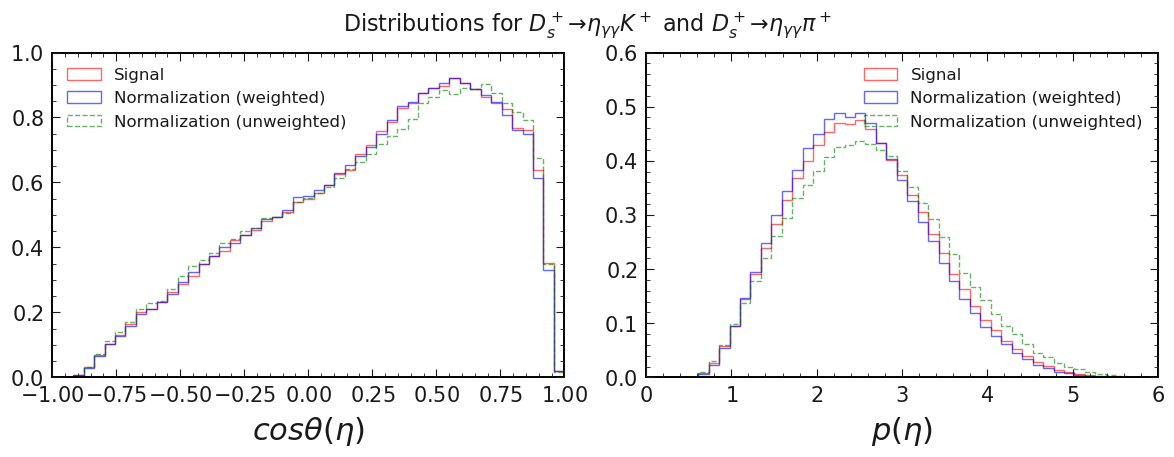

In [53]:
mode = r"$D^+_s \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+_s \to \eta_{\gamma\gamma} \pi^+$"
# === Plot distributions ===
bins_dict = {
    'etapip_Eta_cosTheta': np.linspace(-1, 1, 50),
    'etapip_Eta_p': np.linspace(0, 6, 50),
}

legend_loc = {
    'etapip_Eta_cosTheta': 'upper left',
    'etapip_Eta_p': 'upper right',
}
var_info = {
    'etapip_Eta_cosTheta': r'$cos\theta(\eta)$',
    'etapip_Eta_p': r'$p(\eta)$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Normalization (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['ds_weight'], label='Normalization (unweighted)', linestyle='--', color='green')

    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Distributions for {mode} and {ref_mode}', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"Ds_etapip_gg_K_2_vars_reweighting.pdf")
plt.show()